In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES']='2'
import sys
import random

import numpy as np
import torch
from torch.cuda.memory import set_per_process_memory_fraction
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import OneCycleLR

from gen_bert_embedding import circRNABert, seq2kmer_bert

import torch.utils.data
from transformers import BertModel, BertTokenizer
from utils import read_csv

from MyNet1 import *
from train_loop import train, validate
from utils import read_h5, myDataset, GradualWarmupScheduler, param_num, split_dataset, convert_one_hot

def seq2kmer_bert(seq, k):
    seq_length = len(seq)
    import random
    kmer = [seq[x:x + k] for x in range(seq_length - k + 1)]
    kmers = " ".join(kmer)
    return kmers

max_length = 101

# filename = sys.argv[1] + '.tsv'
# TARDBP_K562

filename = 'TIA1_Hela.tsv'
# filename = 'HNRNPM_K562.tsv'
base_path = '/home/zhuhaoran/MyNet/'

sequences, structs, label = read_csv(base_path + 'clip_data/' + filename)


# 生成bert embedding
model__path = '/home/zhuhaoran/PrismNet-master/3-new-12w-0/'  
tokenizer = BertTokenizer.from_pretrained(model__path, do_lower_case=False)
model = BertModel.from_pretrained(model__path)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
# model = torch.nn.DataParallel(model, device_ids=[0, 1, 2, 3])
model = model.eval()


structure = np.zeros((len(structs), 1, max_length))  # (N, 1, 101)
for i in range(len(structs)):
    struct = structs[i].split(',')
    ti = [float(t) for t in struct]
    ti = np.array(ti).reshape(1, -1)
    structure[i] = np.concatenate([ti], axis=0)

# test_struc = structure
# test_emb = bert_embedding
# test_label = label

[train_seq, train_struc, train_label], [test_seq, test_struc, test_label] = \
    split_dataset(sequences, structure, label, valid_frac=1/30)  # , test_size=0.2, shuffle=True, stratify=label)

test_emb = circRNABert(list(test_seq), model, tokenizer, device, 3)  # default k=3  # (N, 101, 768)
test_emb = test_emb.transpose([0, 2, 1])  # (N, 768, 101)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MyNet10_tmp().to(device)

model_file = '/home/zhuhaoran/MyNet/out/out1/' + filename + '_best.pth'
model.load_state_dict(torch.load(model_file))



test_set = myDataset(test_emb, test_struc, test_label)

test_loader = DataLoader(test_set, batch_size=32 * 8, shuffle=False)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(2))

model.eval()
y_all = []
p_all = []
l_all = []
yyy= []


m_bert = []
m_str = []

with torch.no_grad():
    for batch_idx, (x0, x00, y0) in enumerate(test_loader):
        x, s, y = x0.float().to(device), x00.float().to(device), y0.to(device).float()
        # if y0.sum() ==0:
        #    import pdb; pdb.set_trace()
        output, mbert, mstr = model(x, s)
        loss = criterion(output, y)
        prob = torch.sigmoid(output)  # 将输出控制到[0,1]
        # print(output, prob, y)  # 一个batch

        y_np = y.to(device='cpu', dtype=torch.long).numpy()
        p_np = prob.to(device='cpu').numpy()
        l_np = loss.item()

        y_all.append(y_np)
        p_all.append(p_np)
        l_all.append(l_np)
        yyy.append(output.to(device='cpu', dtype=torch.long).numpy())

        mvbert = mbert.to(device='cpu').numpy()
        mvstr = mstr.to(device='cpu').numpy()

        m_bert.append(mvbert)
        m_str.append(mvstr)


y_all = np.concatenate(y_all)
p_all = np.concatenate(p_all)
yyy = np.concatenate(yyy)
l_all = np.array(l_all)

m_bert = np.concatenate(m_bert)
m_str = np.concatenate(m_str)

# outputs = torch.tensor(yyy)
outputs = torch.tensor(p_all)


index = np.where(p_all>0.99)




# print(test_emb)
# e = shap.GradientExplainer(model, [test_emb, test_struc])



Some weights of the model checkpoint at /home/zhuhaoran/PrismNet-master/3-new-12w-0/ were not used when initializing BertModel: ['cls.predictions.decoder.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
/home/zhuhaoran/anaconda3/envs/graph-bert/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:2301: FutureWarning: The `pad_to_max_length` a

In [2]:
import shap
torch.cuda.empty_cache()
model = MyNet10().to(device)

model_file = '/home/zhuhaoran/MyNet/out/out1/' + filename + '_best.pth'
model.load_state_dict(torch.load(model_file))
test_emb = torch.tensor(test_emb).requires_grad_().to(device).type(torch.float32)
test_struc = torch.tensor(test_struc).requires_grad_().to(device).type(torch.float32)

e = shap.GradientExplainer((model, model.multiscale_bert) , [test_emb, test_struc])
e2 = shap.GradientExplainer((model, model.multiscale_str) , [test_emb, test_struc])

# shap_values = e([test_emb[1:2], test_struc[1:2]])


# shap.plots.waterfall(e.shap_values([test_emb, test_struc]))

torch.Size([499, 768, 99]) torch.Size([499, 1, 101])
torch.Size([499, 768, 99]) torch.Size([499, 1, 101])


In [20]:
from numpy import random

x = random.randint(len(index[0]))
i = index[0][x]
print(i)

90


In [21]:
shap_values_ = e.shap_values([test_emb[index[0][i:i+1]], test_struc[index[0][i:i+1]]])
shap_values_2 = e2.shap_values([test_emb[index[0][i:i+1]], test_struc[index[0][i:i+1]]])

In [26]:
to_plot.shape

(1, 1, 128, 99, 1)

In [27]:
to_plot = np.expand_dims(shap_values_, axis=-1)
# to_plot = np.expand_dims(to_plot, axis=0)


to_plot2 = np.expand_dims(shap_values_2, axis=-1)
# to_plot2 = np.expand_dims(to_plot2, axis=0)


to_explain = np.concatenate([to_plot, to_plot2], axis=0)

data0 = np.expand_dims(m_bert[index[0][i]], axis=-1)
data0 = np.expand_dims(data0, axis=0)
data1 = np.expand_dims(m_str[index[0][i]], axis = -1)
data1 = np.expand_dims(data1, axis=0)
to_plot_data = np.concatenate([data0, data1], axis=0)

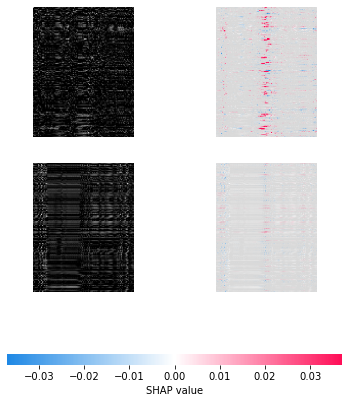

In [28]:
import matplotlib.pyplot as plt
# plt.figure(figsize=(10,1),dpi=150)
# import shap
import importlib
import shap
importlib.reload(shap)

shap.image_plot(to_explain, to_plot_data, dpi=1800, figuresize=(10,50))


# plt.show()


In [7]:
plt.show()

In [8]:
type(shap_values)

NameError: name 'shap_values' is not defined

In [ ]:
type(X)

In [ ]:
X.shape